In [1]:
# ==========================================================
# Notebook 08: BESS for PV self-consumption
#
# Goal:
# Add a simple battery energy storage system (BESS)
# to absorb PV excess and reduce grid import.
#
# This notebook does NOT yet optimize.
# It uses a rule-based strategy:
#
# 1. PV first supplies building load.
# 2. If PV > load, charge the battery with excess PV.
# 3. If PV < load, discharge the battery to reduce grid import.
#
# Later notebooks will add:
# - EV charging flexibility
# - electricity prices
# - optimization
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [2]:
# ==========================================================
# Load yearly OSOPSS data
# ==========================================================

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

In [4]:
# ==========================================================
# Select one day and PV size
# ==========================================================

DAY = 95
S_PV = 300  # PV size [kWp]

hours = np.arange(24)

load_day = load_year[(DAY - 1) * 24 : DAY * 24]
pv_day = S_PV * pv_factor[(DAY - 1) * 24 : DAY * 24]
price_day = price_year[(DAY - 1) * 24 : DAY * 24]

print("Selected day:", DAY)
print("Load energy [kWh]:", load_day.sum())
print("PV energy [kWh]:", pv_day.sum())

Selected day: 95
Load energy [kWh]: 1432.217753386
PV energy [kWh]: 1674.636


In [5]:
# ==========================================================
# BATTERY MODEL PARAMETERS
# ==========================================================
#
# We start with a simple battery model.
#
# The goal is NOT optimization yet.
#
# We simply want to see:
#
# Can a battery absorb excess PV energy
# and later supply the building load?
#
# Battery assumptions:
#
# Capacity = 200 kWh
#
# Maximum charging power:
#     50 kW
#
# Maximum discharging power:
#     50 kW
#
# Charging efficiency:
#     95%
#
# Discharging efficiency:
#     95%
#
# SOC limits:
#     10% to 90%
#
# Initial SOC:
#     50%
#
# Later:
# - battery size will become a decision variable
# - charging/discharging will be optimized
# ==========================================================

E_bess = 200.0          # Battery capacity [kWh]

P_bess_max = 50.0       # Maximum charge/discharge power [kW]

eta_ch = 0.95           # Charging efficiency

eta_dis = 0.95          # Discharging efficiency

SOC_min = 0.10 * E_bess
SOC_max = 0.90 * E_bess

SOC0 = 0.50 * E_bess

print("Battery capacity [kWh]:", E_bess)
print("Initial SOC [kWh]:", SOC0)
print("SOC limits [kWh]:", SOC_min, "to", SOC_max)

Battery capacity [kWh]: 200.0
Initial SOC [kWh]: 100.0
SOC limits [kWh]: 20.0 to 180.0


Battery EMS

In [6]:
# ==========================================================
# SIMPLE PV SELF-CONSUMPTION EMS
# ==========================================================
#
# EMS = Energy Management System
#
# Control philosophy:
#
# CASE 1:
# PV > Load
#
# There is excess solar production.
#
# -> Charge the battery
#
#
# CASE 2:
# PV < Load
#
# Building needs additional energy.
#
# -> Discharge the battery
#
#
# IMPORTANT:
#
# We DO NOT use electricity prices here.
#
# We DO NOT use EV charging here.
#
# We only investigate:
#
# "Can the battery increase PV self-consumption?"
#
# ==========================================================

SOC = np.zeros(24)

P_bess = np.zeros(24)

grid_import = np.zeros(24)

pv_excess = np.zeros(24)

SOC[0] = SOC0

for h in range(24):

    # ------------------------------------------------------
    # Net power balance
    #
    # Positive:
    #     PV exceeds load
    #
    # Negative:
    #     Load exceeds PV
    # ------------------------------------------------------

    net_power = pv_day[h] - load_day[h]

    # ======================================================
    # CASE 1:
    # Excess PV available
    # ======================================================

    if net_power > 0:

        charge_power = min(
            net_power,
            P_bess_max
        )

        P_bess[h] = charge_power

        pv_excess[h] = max(
            net_power - charge_power,
            0
        )

    # ======================================================
    # CASE 2:
    # Building requires energy
    # ======================================================

    else:

        discharge_power = min(
            abs(net_power),
            P_bess_max
        )

        P_bess[h] = -discharge_power

    # ------------------------------------------------------
    # Update SOC
    # ------------------------------------------------------

    if h < 23:

        SOC[h+1] = SOC[h]

        # Charging

        if P_bess[h] > 0:

            SOC[h+1] += (
                P_bess[h] * eta_ch
            )

        # Discharging

        elif P_bess[h] < 0:

            SOC[h+1] += (
                P_bess[h] / eta_dis
            )

        # Respect SOC limits

        SOC[h+1] = np.clip(
            SOC[h+1],
            SOC_min,
            SOC_max
        )

    # ------------------------------------------------------
    # Remaining grid import
    #
    # Load not covered by PV or battery
    # ------------------------------------------------------

    grid_import[h] = max(
        load_day[h]
        - pv_day[h]
        + P_bess[h],
        0
    )

Battery follows PV surplus ~ instead of prices.

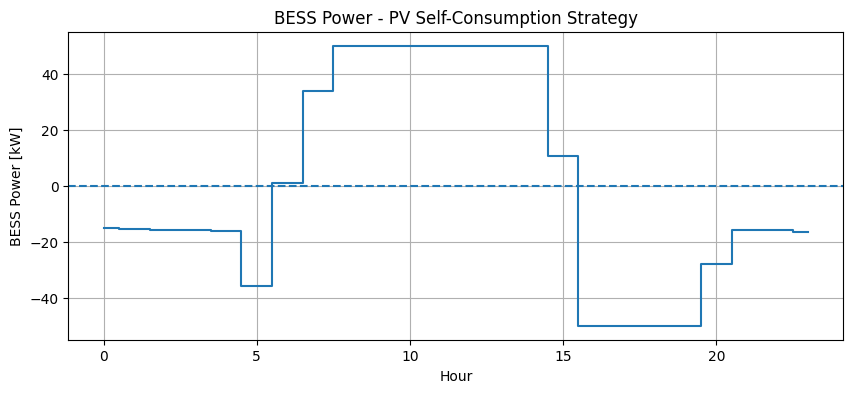

In [7]:
# ==========================================================
# PLOT BESS POWER
#
# Positive P_bess  = battery charging
# Negative P_bess  = battery discharging
# ==========================================================

plt.figure(figsize=(10,4))

plt.step(
    hours,
    P_bess,
    where="mid"
)

plt.axhline(0, linestyle="--")

plt.title("BESS Power - PV Self-Consumption Strategy")
plt.xlabel("Hour")
plt.ylabel("BESS Power [kW]")
plt.grid()

plt.show()

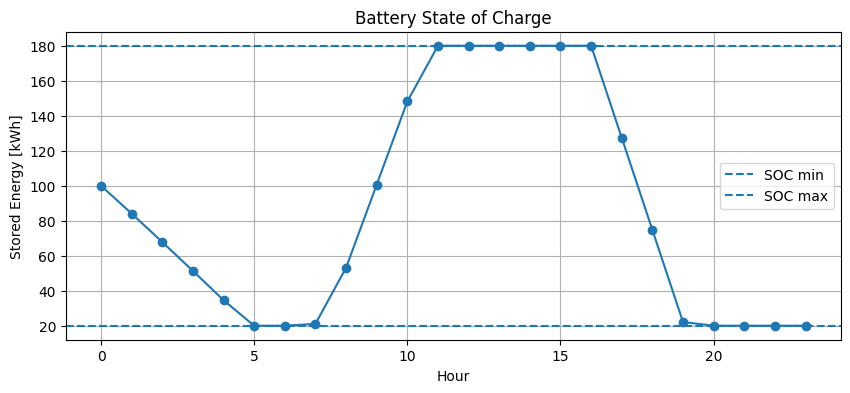

In [8]:
# ==========================================================
# PLOT BATTERY STATE OF CHARGE
#
# SOC shows how much energy is stored inside the battery.
# ==========================================================

plt.figure(figsize=(10,4))

plt.plot(
    hours,
    SOC,
    marker="o"
)

plt.axhline(SOC_min, linestyle="--", label="SOC min")
plt.axhline(SOC_max, linestyle="--", label="SOC max")

plt.title("Battery State of Charge")
plt.xlabel("Hour")
plt.ylabel("Stored Energy [kWh]")
plt.grid()
plt.legend()

plt.show()